# Cox-Time

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn_pandas import DataFrameMapper
import torch
import torchtuples as tt

from pycox.models.cox_time import MLPVanillaCoxTime
from pycox.models import CoxTime
from pycox.evaluation import EvalSurv

In [2]:
SEED = 50

In [3]:
np.random.seed(SEED)
_ = torch.manual_seed(SEED)

## Dataset

In [ ]:
from dataset_PropertyPrice import DatasetHousePrice

ds_name = 'house_price_traj'
ds_df_dir = '/home/yc366/repos/survsurf_benchmark/dataset_split'
project = 'SurvSurfBenchmark_HousePrice'
SAVE_PATH = f'./pycox_models/{project}/cox_time_pycox_{SEED}'
g_resol = 0.01
t_resol = 1
split = 'train'
ds = DatasetHousePrice(
    df_dir=ds_df_dir, 
    ds_name=ds_name, 
    g_resol=g_resol, 
    split=split, 
    mode='first_cross_obs_only', 
    separate_g_from_feats=False
)
df_train = ds._get_df_Xy_trans_obs()

split = 'test'
ds = DatasetHousePrice(
    df_dir=ds_df_dir, 
    ds_name=ds_name, 
    g_resol=g_resol, 
    split=split, 
    mode='first_cross_obs_only', 
    separate_g_from_feats=False
)
df_test = ds._get_df_Xy_true_prob()

split = 'val'
ds = DatasetHousePrice(
    df_dir=ds_df_dir, 
    ds_name=ds_name, 
    g_resol=g_resol, 
    split=split, 
    mode='first_cross_obs_only', 
    separate_g_from_feats=False
)
df_val = ds._get_df_Xy_trans_obs()

In [5]:
df_test

,traj_id,duration,g_max_by_time,event_observed,weight,feat__is_new_build,feat__long,feat__lat,feat__frac_properties_n_beds__1,feat__frac_properties_n_beds__2,...,feat__deprived_3_dim,feat__deprived_4_dim,feat__soc_grade_AB,feat__soc_grade_C1,feat__soc_grade_C2,feat__soc_grade_DE,feat__prop_type_Detached,feat__prop_type_SemiD,feat__prop_type_Terraced,is_t_trans
0,E06000001SemiNew,1,1.0,0.0,1,1.0,0.021889,2.090930,-0.504054,-0.504811,...,1.604944,0.088157,-1.329559,-1.741656,0.500371,1.905991,0.0,1.0,0.0,NaN
1,E06000001SemiNew,2,1.0,0.0,1,1.0,0.021889,2.090930,-0.504054,-0.504811,...,1.604944,0.088157,-1.329559,-1.741656,0.500371,1.905991,0.0,1.0,0.0,NaN
2,E06000001SemiNew,3,1.0,0.0,1,1.0,0.021889,2.090930,-0.504054,-0.504811,...,1.604944,0.088157,-1.329559,-1.741656,0.500371,1.905991,0.0,1.0,0.0,NaN
3,E06000001SemiNew,4,1.0,0.0,1,1.0,0.021889,2.090930,-0.504054,-0.504811,...,1.604944,0.088157,-1.329559,-1.741656,0.500371,1.905991,0.0,1.0,0.0,NaN
4,E06000001SemiNew,5,1.0,NaN,1,1.0,0.021889,2.090930,-0.504054,-0.504811,...,1.604944,0.088157,-1.329559,-1.741656,0.500371,1.905991,0.0,1.0,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13995,W06000024TerracedExisting,3,0.1,1.0,1,0.0,-1.530934,-0.521543,-0.507739,-0.313532,...,2.923401,1.212583,-1.515403,-1.384008,0.305800,2.075228,0.0,0.0,1.0,NaN
13996,W06000024TerracedExisting,4,0.1,1.0,1,0.0,-1.530934,-0.521543,-0.507739,-0.313532,...,2.923401,1.212583,-1.515403,-1.384008,0.305800,2.075228,0.0,0.0,1.0,NaN
13997,W06000024TerracedExisting,5,0.1,1.0,1,0.0,-1.530934,-0.521543,-0.507739,-0.313532,...,2.923401,1.212583,-1.515403,-1.384008,0.305800,2.075228,0.0,0.0,1.0,NaN
13998,W06000024TerracedExisting,6,0.1,1.0,1,0.0,-1.530934,-0.521543,-0.507739,-0.313532,...,2.923401,1.212583,-1.515403,-1.384008,0.305800,2.075228,0.0,0.0,1.0,NaN


In [6]:
df_train.head()

,traj_id,event_observed,duration,g_max_by_time,feat__is_new_build,feat__long,feat__lat,feat__frac_properties_n_beds__1,feat__frac_properties_n_beds__2,feat__frac_properties_n_beds__3,...,feat__deprived_4_dim,feat__soc_grade_AB,feat__soc_grade_C1,feat__soc_grade_C2,feat__soc_grade_DE,feat__prop_type_Detached,feat__prop_type_SemiD,feat__prop_type_Terraced,weight,is_t_trans
0,E06000001DetachedExisting,1,1.0,0.000580,0.0,0.021889,2.09093,-0.553782,-0.876423,-0.709005,...,0.088157,-1.329559,-1.741656,0.500371,1.905991,1.0,0.0,0.0,1,1
1,E06000001DetachedExisting,1,3.0,0.008855,0.0,0.021889,2.09093,-0.553782,-0.876423,-0.709005,...,0.088157,-1.329559,-1.741656,0.500371,1.905991,1.0,0.0,0.0,1,1
2,E06000001DetachedExisting,1,4.0,0.035069,0.0,0.021889,2.09093,-0.553782,-0.876423,-0.709005,...,0.088157,-1.329559,-1.741656,0.500371,1.905991,1.0,0.0,0.0,1,1
3,E06000001DetachedExisting,1,5.0,0.063205,0.0,0.021889,2.09093,-0.553782,-0.876423,-0.709005,...,0.088157,-1.329559,-1.741656,0.500371,1.905991,1.0,0.0,0.0,1,1
4,E06000001DetachedExisting,1,6.0,0.206230,0.0,0.021889,2.09093,-0.553782,-0.876423,-0.709005,...,0.088157,-1.329559,-1.741656,0.500371,1.905991,1.0,0.0,0.0,1,1


## Feature transforms

In [7]:
x_train = df_train.loc[:,df_train.columns.str.startswith('feat')|df_train.columns.str.startswith('g_max_by_time')].astype('float32')
x_train['g_max_by_time'] = x_train['g_max_by_time']/ds.g_max
x_train = x_train.values

x_val = df_val.loc[:,df_val.columns.str.startswith('feat')|df_val.columns.str.startswith('g_max_by_time')].astype('float32')
x_val['g_max_by_time'] = x_val['g_max_by_time']/ds.g_max
x_val = x_val.values

x_test = df_test.loc[:,df_test.columns.str.startswith('feat')|df_test.columns.str.startswith('g_max_by_time')].drop_duplicates().astype('float32')
x_test['g_max_by_time'] = x_test['g_max_by_time']/ds.g_max
x_test = x_test.values



In [8]:
df_train.loc[:,df_train.columns.str.startswith('feat')|df_train.columns.str.startswith('g_max_by_time')].columns == (
    df_test.loc[:,df_test.columns.str.startswith('feat')|df_test.columns.str.startswith('g_max_by_time')].columns
)

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True])

We need no label transforms

In [9]:
get_target = lambda df: (df['duration'].astype('float32').values, df['event_observed'].astype('float32').values)
y_train = get_target(df_train)
y_val = get_target(df_val)
durations_test, events_test = get_target(df_test)
val = tt.tuplefy(x_val, y_val)

In [10]:
val.shapes()

((1067, 53), ((1067,), (1067,)))

With `TupleTree` (the results of `tt.tuplefy`) we can easily repeat the validation dataset multiple times. This will be useful for reduce the variance of the validation loss, as the validation loss of `CoxTime` is not deterministic.

In [11]:
val.repeat(2).cat().shapes()

((2134, 53), ((2134,), (2134,)))

## Neural net
 
We create a simple MLP with two hidden layers, ReLU activations, batch norm and dropout. 
The net required by `CoxTime` is slightly different than most of the other methods as it also take `time` and an additional input argument. 
We have therefore crated the `MLPVanillaCoxTime` class that is a suitable version of `tt.practical.MLPVanilla`.
This class also removes the options for setting `out_features` and `output_bias` as they should be `1` and `False`, respectively.
 
To see the code for the networks call `??MLPVanillaCoxTime`.

In [12]:
in_features = x_train.shape[1]
num_nodes = [64, 64, 64, 64]
batch_norm = False
dropout = 0

net = MLPVanillaCoxTime(in_features, num_nodes, batch_norm, dropout)

## Training the model

In [13]:
#model = CoxTime(net, tt.optim.Adam(lr=1e-2, weight_decay=1e-2))
model = CoxTime(net, tt.optim.Adam(lr=2e-3, weight_decay=2e-3))
# model = CoxTime(net, tt.optim.Adam(lr=1e-6, weight_decay=5e-3))

In [14]:
batch_size = 64

We include the `EarlyStopping` callback to stop training when the validation loss stops improving. After training, this callback will also load the best performing model in terms of validation loss.

In [15]:
epochs = 2000
callbacks = [tt.callbacks.EarlyStopping(patience=500)]
verbose = True

In [16]:
%%time
log = model.fit(x_train, y_train, batch_size, epochs, callbacks, verbose,
                val_data=val.repeat(10).cat())

0:	[0s / 0s],		train_loss: 0.6984,	val_loss: 0.6915
1:	[0s / 1s],		train_loss: 0.6864,	val_loss: 0.6903
2:	[0s / 2s],		train_loss: 0.6473,	val_loss: 0.6624
3:	[0s / 3s],		train_loss: 0.5912,	val_loss: 0.6476
4:	[0s / 3s],		train_loss: 0.5574,	val_loss: 0.6612
5:	[0s / 4s],		train_loss: 0.5399,	val_loss: 0.6174
6:	[0s / 5s],		train_loss: 0.5216,	val_loss: 0.6234
7:	[0s / 5s],		train_loss: 0.5087,	val_loss: 0.6066
8:	[0s / 6s],		train_loss: 0.5063,	val_loss: 0.6046
9:	[0s / 7s],		train_loss: 0.5062,	val_loss: 0.6092
10:	[0s / 8s],		train_loss: 0.4939,	val_loss: 0.5931
11:	[0s / 8s],		train_loss: 0.4776,	val_loss: 0.6235
12:	[0s / 9s],		train_loss: 0.4937,	val_loss: 0.6003
13:	[0s / 9s],		train_loss: 0.4822,	val_loss: 0.5960
14:	[0s / 10s],		train_loss: 0.4805,	val_loss: 0.5880
15:	[0s / 10s],		train_loss: 0.4755,	val_loss: 0.6089
16:	[0s / 11s],		train_loss: 0.4805,	val_loss: 0.6159
17:	[0s / 11s],		train_loss: 0.4725,	val_loss: 0.5930
18:	[0s / 12s],		train_loss: 0.4788,	val_loss: 0.587

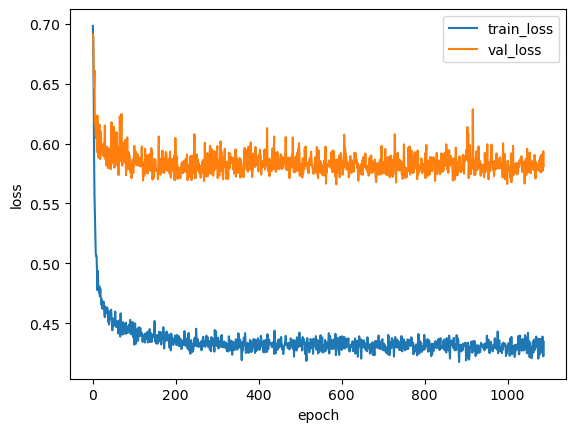

In [17]:
_ = log.plot()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.savefig(f'{SAVE_PATH}_training_curves.pdf')
log.to_pandas().to_csv(f'{SAVE_PATH}_training_curves.csv')

We can get the partial log-likelihood

In [18]:
model.partial_log_likelihood(*val).mean()

-5.9449215

## Prediction

For evaluation we first need to obtain survival estimates for the test set.
This can be done with `model.predict_surv` which returns an array of survival estimates, or with `model.predict_surv_df` which returns the survival estimates as a dataframe.

However, as `CoxCC` is semi-parametric, we first need to get the non-parametric baseline hazard estimates with `compute_baseline_hazards`. 

Note that for large datasets the `sample` argument can be used to estimate the baseline hazard on a subset.

In [19]:
_ = model.compute_baseline_hazards()

In [20]:
x_test.shape

(2000, 53)

In [21]:
x_test

array([[ 1.        ,  1.        ,  0.02188914, ...,  0.        ,
         1.        ,  0.        ],
       [ 0.5       ,  1.        ,  0.02188914, ...,  0.        ,
         1.        ,  0.        ],
       [ 0.33333334,  1.        ,  0.02188914, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [ 0.125     ,  0.        , -1.5309342 , ...,  0.        ,
         0.        ,  1.        ],
       [ 0.11111111,  0.        , -1.5309342 , ...,  0.        ,
         0.        ,  1.        ],
       [ 0.1       ,  0.        , -1.5309342 , ...,  0.        ,
         0.        ,  1.        ]], dtype=float32)

In [22]:
surv = model.predict_surv_df(x_test)

In [23]:
surv

,0,1,2,3,4,5,6,7,8,9,...,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999
duration,,,,,,,,,,,,,,,,,,,,,
1.0,0.999884,0.999634,0.992615,0.981554,0.976256,0.968840,0.962189,0.956306,0.951121,0.946546,...,0.999997,0.999995,0.999987,0.999905,0.999464,0.997879,0.994339,0.988201,0.979155,0.967217
2.0,0.999509,0.997719,0.958688,0.938886,0.927263,0.906210,0.886933,0.870106,0.855450,0.842653,...,0.999994,0.999989,0.999925,0.999221,0.994052,0.976548,0.938352,0.875177,0.785139,0.670740
3.0,0.998510,0.983827,0.902363,0.868978,0.847757,0.808221,0.771479,0.741727,0.719924,0.701385,...,0.999988,0.999977,0.999393,0.991096,0.913612,0.654342,0.484098,0.385277,0.305909,0.257338
4.0,0.994547,0.924057,0.815746,0.765879,0.737193,0.686880,0.652205,0.624849,0.604792,0.587885,...,0.999975,0.999923,0.990273,0.813772,0.521826,0.331222,0.233234,0.182150,0.142634,0.118642
5.0,0.969696,0.790649,0.674427,0.625906,0.598043,0.554584,0.521798,0.496204,0.477422,0.461550,...,0.999926,0.998856,0.725795,0.449777,0.253461,0.145643,0.097358,0.074471,0.057358,0.047072
6.0,0.810519,0.609412,0.503121,0.446191,0.416092,0.390512,0.370497,0.354053,0.341770,0.331267,...,0.999577,0.945351,0.380118,0.213442,0.104770,0.053346,0.032384,0.022905,0.017022,0.013723
7.0,0.632740,0.448244,0.354155,0.315522,0.296538,0.281275,0.268314,0.257439,0.249277,0.242210,...,0.996011,0.601550,0.206562,0.107358,0.048999,0.022491,0.012570,0.008314,0.005845,0.004498


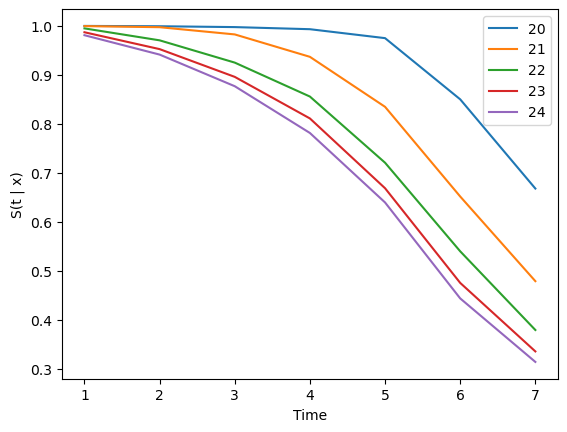

In [24]:
n = 5
surv.iloc[:, 5*(n-1):5*n].plot()
plt.ylabel('S(t | x)')
_ = plt.xlabel('Time')

In [25]:
model.save_net(SAVE_PATH)